# Part 1 — Risk-Neutral Implied Distributions from Option Smiles

In this first part of the project we aim to extract the risk-neutral marginal distributions for each of our five AI-sector equities: Nvidia (NVDA), Palantir (PLTR), Microsoft (MSFT), Seagate Technology (STX), and Alphabet (GOOGL). We do so by recovering, for each asset, the probability distribution that the options market implicitly assigns to its future price at a given expiry date. Here is a brief description of what this notebook will cover:

For each asset we download the full option chain from Yahoo Finance. Rather than picking a fixed expiry date, we scan all expiries between 14 and 90 days from today and select the one with the most liquid OTM strikes, with a preference for expiries near 45 days. This ensures we work with the richest and most informative smile available.

Raw option prices are converted to implied volatilities by numerically inverting the Black-Scholes formula at each strike. We keep only out-of-the-money options since these are more liquid and carry the most information about market expectations in the tails.

The discrete implied volatility points are then fitted with a smooth continuous function. We use two approaches depending on data availability. When 20 or more strike points are present we fit the SVI (Stochastic Volatility Inspired) model, a five-parameter parametric form that is widely used in quantitative finance for its ability to capture skew and curvature while remaining free of static arbitrage by construction. When fewer points are
available SVI becomes unreliable due to overfitting, so we fall back to a smoothing spline in log-moneyness space, which imposes smoothness without requiring a specific functional form.

Given the smooth call pricing function, we apply the Breeden-Litzenberger formula, which states that the risk-neutral density is proportional to the second derivative of the call price with respect to strike: q(S_T) = e^(rT) * d²C/dK². We reprice calls on a dense strike grid, enforce monotone decreasing prices via isotonic regression to eliminate numerical noise and differentiate using a Savitzky-Golay filter, which fits local polynomials to compute derivatives and is significantly more stable than applying finite differences twice.

Finally the PDF is integrated to produce the CDF for each asset. 

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
from functions_marginal_distributions import *
import matplotlib.pyplot as plt

In [7]:
tickers = ["NVDA", "PLTR", "MSFT", "STX", "GOOGL"]

We first import the data that we need for each ticker

In [8]:
data = {}
for ticker in tickers:
    data[ticker] = fetch_option_chain(ticker)

Then we build the volatility smile and use it to compute the marginal distributions

In [9]:
results = {}
for ticker in tickers:
    asset = data[ticker]
    smile = build_smile(asset)
    S     = asset["spot"]
    T     = smile["T"].iloc[0]

    smile_params, method = fit_smile(smile, ticker)
    K_grid, pdf = breeden_litzenberger(
            smile_params, S, T, r=0.05, method=method
        )
    cdf = extract_cdf(K_grid, pdf)
    results[ticker] = {
            "S": S, "T": T, "smile": smile,
            "smile_params": smile_params, "method": method,
            "K_grid": K_grid, "pdf": pdf, "cdf": cdf,
        }


Then we plot the results

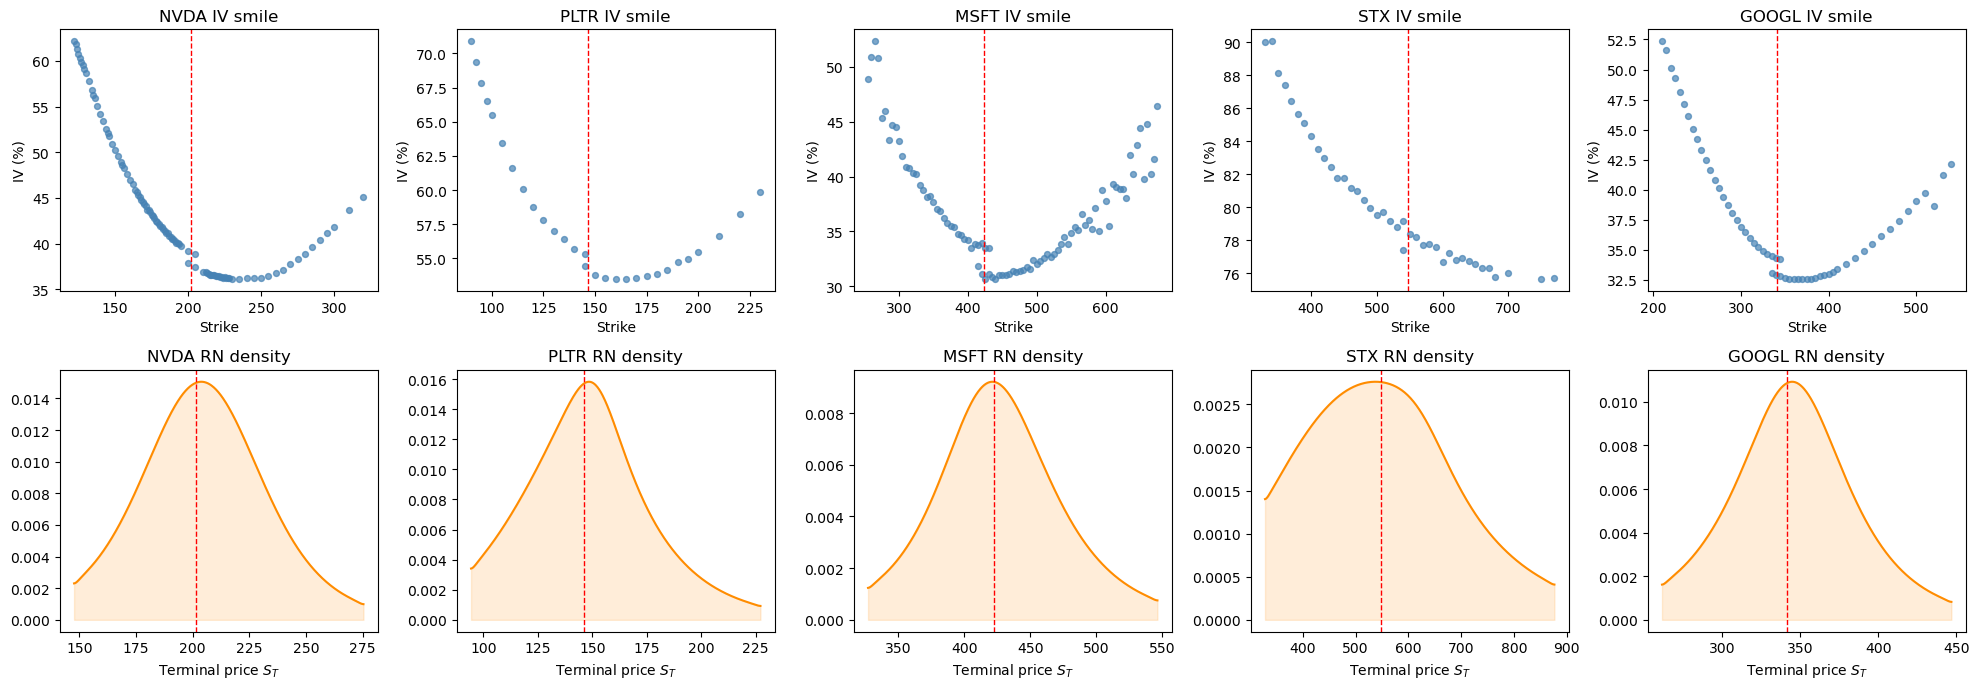

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for i, ticker in enumerate(tickers):
    r = results[ticker]

    sm = r["smile"]
    axes[0, i].scatter(sm["strike"], sm["iv"] * 100,
                       s=18, alpha=0.7, color="steelblue")
    axes[0, i].set_title(f"{ticker} IV smile")
    axes[0, i].set_xlabel("Strike"); axes[0, i].set_ylabel("IV (%)")
    axes[0, i].axvline(r["S"], color="red", lw=1, linestyle="--",
                       label="Spot")

    axes[1, i].plot(r["K_grid"], r["pdf"], color="darkorange", lw=1.5)
    axes[1, i].fill_between(r["K_grid"], r["pdf"], alpha=0.15,
                             color="darkorange")
    axes[1, i].axvline(r["S"], color="red", lw=1, linestyle="--")
    axes[1, i].set_title(f"{ticker} RN density")
    axes[1, i].set_xlabel("Terminal price $S_T$")

plt.tight_layout()
plt.show()

Finally we save the results in a cvs file for the next phases of the project

In [11]:
rows = []
for ticker in tickers:
    r = results[ticker]
    for k, p, c in zip(r["K_grid"], r["pdf"], r["cdf"]):
        rows.append({
            "ticker": ticker,
            "S":      r["S"],
            "T":      r["T"],
            "K":      k,
            "pdf":    p,
            "cdf":    c
        })

df_out = pd.DataFrame(rows)
df_out.to_csv("marginal_dist.csv", index=False)